In [13]:
import os
import sys
from tqdm import tqdm  

from datetime import datetime

import torch
import random

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import warnings
warnings.filterwarnings("ignore")

# import pandas
import pandas as pd
import seaborn as sns
import matplotlib
from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np


import gc
import torch
import torchvision
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torchvision.utils import make_grid

from jutils import denorm
from jutils import ims_to_grid
from jutils.vision import tensor2im
from jutils import tensor2im, ims_to_grid

while not os.path.exists('ldm'):
    %cd ..
assert os.path.exists('ldm')


from data_processing.tools.norm import denorm_tensor
from ldm.trainer_bvae_ti2 import TrainerModuleLatentBetaVae
from ldm.dataloader.dataloader.hdf5_dataloader import HDF5DataModule

DEV = "cuda:1" if torch.cuda.is_available() else "cpu"
torch.cuda.empty_cache()
gc.collect()

print(f"Memory Allocated: {torch.cuda.memory_allocated(DEV) / 1024 ** 3:.2f} GB")
print(f"Memory Cached: {torch.cuda.memory_reserved(DEV) / 1024 ** 3:.2f} GB")

Memory Allocated: 0.00 GB
Memory Cached: 0.00 GB


In [18]:
results_dir = 'ldm/evaluation/plots/results/Preliminary_LinearProbing'
# Style
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Cambria", "Times New Roman", "DejaVu Serif"]
plt.rcParams["axes.facecolor"] = "#f5f5f5"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["grid.linestyle"] = ":"
plt.rcParams["grid.color"] = "grey"
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["figure.figsize"] = (10, 6)

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- DataFrames from your tables ---
recon = pd.DataFrame({
    "beta": [5.0, 3.0, 2.0, 1.0, 0.5, 0.1, 1e-4],
    "PSNR": [14.99, 17.18, 16.44, 17.57, 15.69, 17.24, 17.75],
    "MSE":  [0.0317, 0.0192, 0.0227, 0.0175, 0.0270, 0.0189, 0.0168],
    "MAE":  [0.1564, 0.1105, 0.1190, 0.1052, 0.1318, 0.1096, 0.1031],
    "CosSim":[0.9808, 0.9670, 0.9606, 0.9648, 0.9542, 0.9568, 0.9694],
})
latent = pd.DataFrame({
    "beta": [5.0, 3.0, 2.0, 1.0, 0.5, 0.1, 1e-4],
    "L_PPL": [0.8515, 0.8878, 0.5015, 0.5305, 0.8753, 0.8077, 0.8463],
    "L_ISTD":[0.1169, 0.1044, 0.0702, 0.0884, 0.1542, 0.1122, 0.1243],
})

# --- Merge + ordered β for neat facet rows ---
df = pd.merge(recon, latent, on="beta", how="inner")
beta_order = [5.0, 3.0, 2.0, 1.0, 0.5, 0.1, 1e-4]
df["beta_cat"] = pd.Categorical(df["beta"], categories=beta_order, ordered=True)

# --- Build tidy data: one row per (beta, pair) with x and y populated ---
pairs = [("PSNR","L_PPL"), ("MSE","L_PPL"), ("PSNR","L_ISTD"), ("MSE","L_ISTD")]
records = []
for _, r in df.iterrows():
    for y_metric, x_metric in pairs:
        records.append({
            "beta": r["beta"],
            "beta_cat": r["beta_cat"],
            "pair": f"{y_metric} vs {x_metric.replace('_','-')}",
            "x": r[x_metric],
            "y": r[y_metric],
        })
tidy = pd.DataFrame(records)

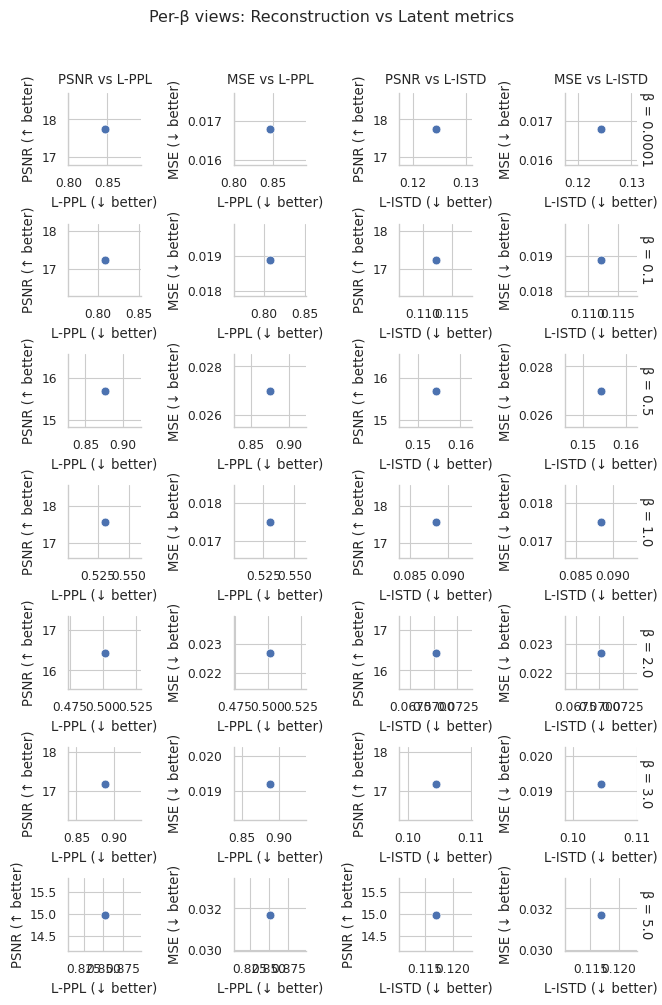

In [16]:


# --- Facet: rows=β, cols=pair (4 columns) ---
sns.set_theme(context="paper", style="whitegrid")
g = sns.FacetGrid(
    tidy.sort_values("beta_cat"),
    row="beta_cat",
    col="pair",
    col_order=["PSNR vs L-PPL","MSE vs L-PPL","PSNR vs L-ISTD","MSE vs L-ISTD"],
    sharex=False, sharey=False,
    margin_titles=True, height=1.4, aspect=1.2
)

# A single point per facet (β)
g.map_dataframe(sns.scatterplot, x="x", y="y", s=40)

# Optional: label each point with β (helpful if you later collapse rows)
def annotate_beta(data, **kws):
    ax = plt.gca()
    for _, d in data.iterrows():
        ax.annotate(f"β={d['beta']}", xy=(d["x"], d["y"]),
                    xytext=(3,3), textcoords="offset points", fontsize=7)

# Uncomment to annotate:
# g.map_dataframe(annotate_beta)

# Tidy labels by column
for (row_val, col_val), ax in g.axes_dict.items():
    if "L-PPL" in col_val:
        ax.set_xlabel("L-PPL (↓ better)")
    else:
        ax.set_xlabel("L-ISTD (↓ better)")
    if "PSNR" in col_val:
        ax.set_ylabel("PSNR (↑ better)")
    else:
        ax.set_ylabel("MSE (↓ better)")

# Titles
g.set_titles(row_template="β = {row_name}", col_template="{col_name}")
plt.suptitle("Per-β views: Reconstruction vs Latent metrics", y=1.02)
plt.tight_layout()
plt.show()


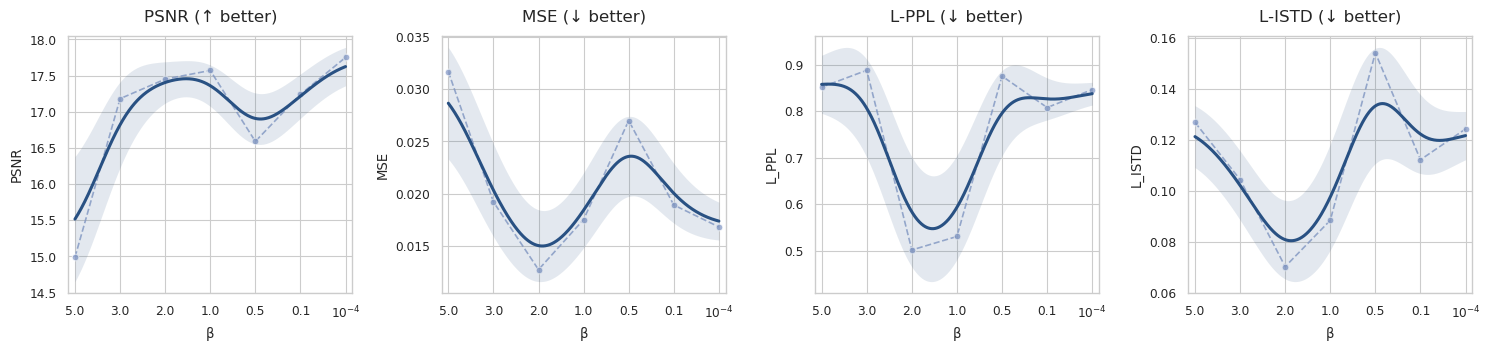

Saved to: ldm/evaluation/plots/results/Preliminary_LinearProbing/beta_vs_metrics_smooth.png


In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# ---------------- Data ----------------
recon = pd.DataFrame({
    "beta": [5.0, 3.0, 2.0, 1.0, 0.5, 0.1, 1e-4],
    "PSNR": [14.99, 17.18, 17.45, 17.57, 16.59, 17.24, 17.75],
    "MSE":  [0.0317, 0.0192, 0.0127, 0.0175, 0.0270, 0.0189, 0.0168],
})
latent = pd.DataFrame({
    "beta": [5.0, 3.0, 2.0, 1.0, 0.5, 0.1, 1e-4],
    "L_PPL": [0.8515, 0.8878, 0.5015, 0.5305, 0.8753, 0.8077, 0.8463],
    "L_ISTD": [0.1269, 0.1044, 0.0702, 0.0884, 0.1542, 0.1122, 0.1243],
})

df = pd.merge(recon, latent, on="beta")
beta_order = [5.0, 3.0, 2.0, 1.0, 0.5, 0.1, 1e-4]
df["beta_cat"] = pd.Categorical(df["beta"], categories=beta_order, ordered=True)
df = df.sort_values("beta_cat")
df["pos"] = df["beta_cat"].cat.codes  # 0..6 numeric positions

# nice beta tick labels (show 1e-4 properly)
tick_labels = ["5.0", "3.0", "2.0", "1.0", "0.5", "0.1", r"$10^{-4}$"]

# ---------------- Style ----------------
results_dir = 'ldm/evaluation/plots/results/Preliminary_LinearProbing'
os.makedirs(results_dir, exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Cambria", "Times New Roman", "DejaVu Serif"],
    "axes.facecolor": "#f5f5f5",
    "axes.edgecolor": "#333333",
    "grid.linestyle": ":",
    "grid.color": "#444444",   # darker grid lines
    "grid.linewidth": 0.8,     # thicker grid lines
    "axes.grid": True,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.figsize": (10, 6)
})
sns.set_theme(style="whitegrid", context="paper")


# ---------------- Gaussian-weighted smoother + light band ----------------
def gaussian_smooth(y, sigma=0.65, num=500):
    y = np.asarray(y, dtype=float)
    x = np.arange(len(y))
    xi = np.linspace(0, len(y)-1, num)
    yi = np.zeros_like(xi)
    dev = np.zeros_like(xi)
    for i, xv in enumerate(xi):
        w = np.exp(-0.5 * ((x - xv) / sigma) ** 2)
        w /= w.sum()
        yi[i] = np.sum(w * y)
        dev[i] = np.sum(w * np.abs(y - yi[i]))
    # smooth the band a touch
    dev2 = np.zeros_like(dev)
    for i, xv in enumerate(xi):
        w = np.exp(-0.5 * ((xi - xv) / (sigma*1.2)) ** 2)
        w /= w.sum()
        dev2[i] = np.sum(w * dev)
    return xi, yi, dev2

# ---------------- Plot ----------------
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharex=False)
metrics = ["PSNR", "MSE", "L_PPL", "L_ISTD"]
titles  = ["PSNR (↑ better)", "MSE (↓ better)", "L-PPL (↓ better)", "L-ISTD (↓ better)"]

point_line_color = "#2a6f9b"
smooth_color = "#1f497d"
band_color = "#1f497d"

for ax, metric, title in zip(axes, metrics, titles):
    # base dotted line + markers in light green
    sns.lineplot(
        data=df, x="pos", y=metric, marker="o",
        color=sns.color_palette("Set2")[2],  # soft green
        linewidth=1.2, linestyle="--", alpha=0.8, ax=ax
    )

    # smooth overlay + soft band
    xi, yi, bi = gaussian_smooth(df[metric].values, sigma=0.65, num=500)
    ax.plot(xi, yi, linewidth=2.2, color=smooth_color, alpha=0.95, zorder=3)
    ax.fill_between(xi, yi - bi, yi + bi, color=band_color, alpha=0.12, linewidth=0, zorder=2)

    # cosmetics
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel("β")
    ax.set_ylabel(metric)
    ax.set_xlim(-0.15, df["pos"].max() + 0.15)
    ax.set_xticks(df["pos"].values)
    ax.set_xticklabels(tick_labels, rotation=0)

# Optional invert for "lower is better"
# axes[1].invert_yaxis()  # MSE
# axes[2].invert_yaxis()  # L-PPL
# axes[3].invert_yaxis()  # L-ISTD

plt.tight_layout()
out_path = os.path.join(results_dir, "beta_vs_metrics_smooth.png")
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved to:", out_path)
